In [1]:
import pandas as pd
import numpy as np

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("url_spam_classification.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 148303
Columns : 2


In [4]:
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [5]:
df.tail()

,url,is_spam
148298,"https://cdn.substack.com/image/fetch/f_auto,q_...",True
148299,https://numlock.substack.com/subscribe,True
148300,https://docs.google.com/forms/d/e/1FAIpQLSfDLO...,True
148301,https://bookclub.substack.com/,True
148302,https://awards.substack.com/,True


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148303 entries, 0 to 148302
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   url      148303 non-null  str  
 1   is_spam  148303 non-null  bool 
dtypes: bool(1), str(1)
memory usage: 11.4 MB


In [7]:
df["is_spam"].value_counts()

is_spam
False    101021
True      47282
Name: count, dtype: int64

In [8]:
(df["is_spam"].value_counts(normalize=True) * 100).round(2)

is_spam
False    68.12
True     31.88
Name: proportion, dtype: float64

In [9]:
(df.isnull().mean() * 100)

url        0.0
is_spam    0.0
dtype: float64

In [10]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 60722


In [11]:
duplicate_urls = df["url"].duplicated().sum()

print(f"Duplicate URLs: {duplicate_urls}")

Duplicate URLs: 60722


In [12]:
df.dtypes

url         str
is_spam    bool
dtype: object

In [13]:
df.nunique()

url        87581
is_spam        2
dtype: int64

In [14]:
df.describe(include="all")

,url,is_spam
count,148303,148303
unique,87581,2
top,https://www.bloomberg.com/tosv2.html,False
freq,1086,101021


In [15]:
df["url_length"] = df["url"].str.len()

In [16]:
df["url_length"].describe()

count    148303.000000
mean         71.343257
std          37.266596
min          13.000000
25%          43.000000
50%          66.000000
75%          93.000000
max         511.000000
Name: url_length, dtype: float64

In [17]:
memory = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage: {memory:.2f} MB")

Memory Usage: 12.49 MB


In [18]:
df.drop(columns=["url_length"], inplace=True)

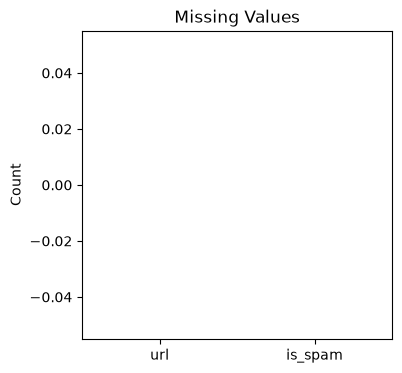

In [19]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(4,4))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

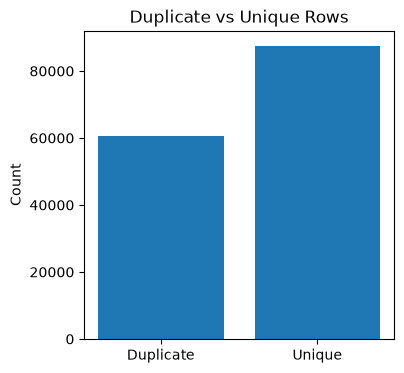

In [20]:
duplicates = df.duplicated().sum()

plt.figure(figsize=(4,4))
plt.bar(["Duplicate","Unique"],
        [duplicates, len(df)-duplicates])
plt.title("Duplicate vs Unique Rows")
plt.ylabel("Count")
plt.show()

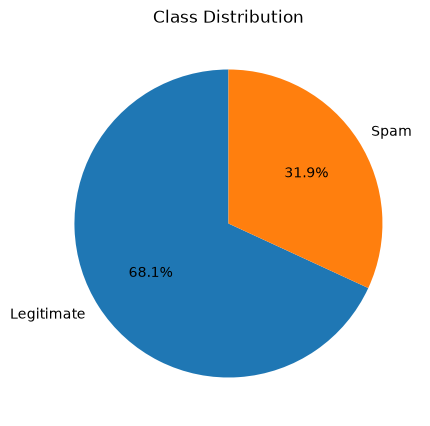

In [21]:
class_counts = df["is_spam"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    class_counts,
    labels=["Legitimate","Spam"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Class Distribution")
plt.show()

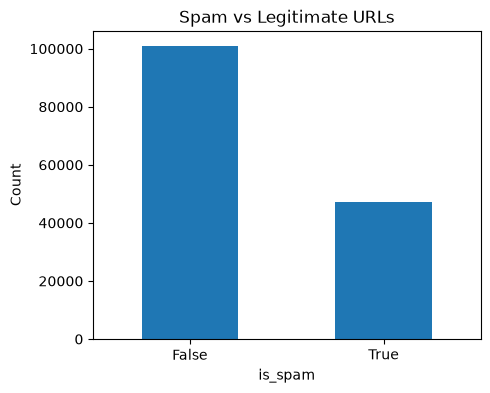

In [22]:
plt.figure(figsize=(5,4))

class_counts.plot(kind="bar")

plt.title("Spam vs Legitimate URLs")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [23]:
df["url_length"] = df["url"].str.len()

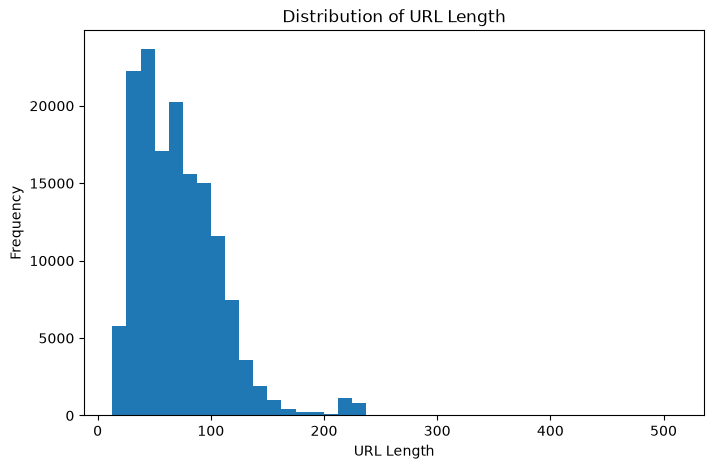

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df["url_length"], bins=40)

plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.title("Distribution of URL Length")

plt.show()

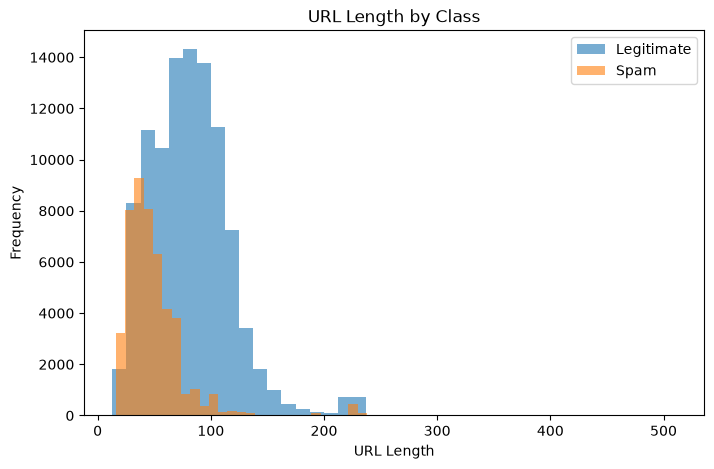

In [25]:
spam = df[df["is_spam"]]["url_length"]
legit = df[~df["is_spam"]]["url_length"]

plt.figure(figsize=(8,5))

plt.hist(legit, bins=40, alpha=0.6, label="Legitimate")
plt.hist(spam, bins=40, alpha=0.6, label="Spam")

plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.title("URL Length by Class")
plt.legend()

plt.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_17312\1265330411.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["url_length"], vert=False)


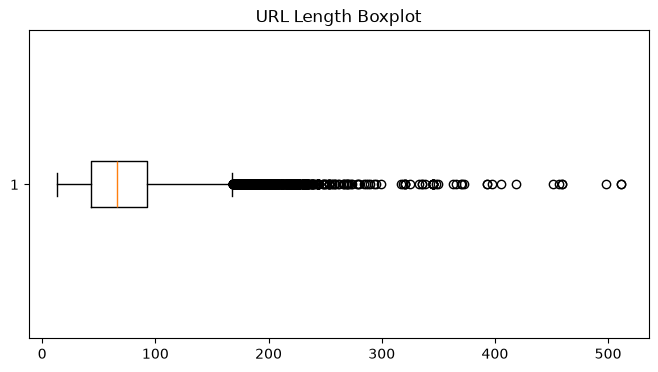

In [26]:
plt.figure(figsize=(8,4))

plt.boxplot(df["url_length"], vert=False)

plt.title("URL Length Boxplot")

plt.show()

In [27]:
df_clean = df.copy()

In [28]:
print("Shape Before:", df_clean.shape)

df_clean.drop_duplicates(subset="url", inplace=True)

print("Shape After :", df_clean.shape)

Shape Before: (148303, 3)
Shape After : (87581, 3)


In [29]:
print("Remaining Duplicate URLs:", df_clean["url"].duplicated().sum())

Remaining Duplicate URLs: 0


In [30]:
df_clean.isnull().sum()

url           0
is_spam       0
url_length    0
dtype: int64

In [31]:
empty_urls = (df_clean["url"].str.strip() == "").sum()

print("Empty URLs:", empty_urls)

Empty URLs: 0


In [32]:

df_clean["is_spam"].unique()

array([ True, False])

In [33]:
df_clean["is_spam"].value_counts()

is_spam
False    84796
True      2785
Name: count, dtype: int64

In [35]:
df_clean["is_spam"] = df_clean["is_spam"].astype(int)
df_clean["is_spam"].unique()

array([1, 0])

In [36]:
from urllib.parse import urlparse

def is_valid_url(url):
    parsed = urlparse(url)
    return bool(parsed.scheme and parsed.netloc)

df_clean["valid_url"] = df_clean["url"].apply(is_valid_url)

df_clean["valid_url"].value_counts()

valid_url
True    87581
Name: count, dtype: int64

In [37]:
df_clean.drop(columns="valid_url", inplace=True)

In [38]:
df_clean.reset_index(drop=True, inplace=True)

In [39]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 87581 entries, 0 to 87580
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   url         87581 non-null  str  
 1   is_spam     87581 non-null  int64
 2   url_length  87581 non-null  int64
dtypes: int64(2), str(1)
memory usage: 8.7 MB


In [40]:
df_clean.head()

,url,is_spam,url_length
0,https://briefingday.us8.list-manage.com/unsubs...,1,51
1,https://www.hvper.com/,1,22
2,https://briefingday.com/m/v4n3i4f3,1,34
3,https://briefingday.com/n/20200618/m#commentform,0,48
4,https://briefingday.com/fan,1,27


In [41]:
df_clean.shape

(87581, 3)

In [43]:
df_clean.to_csv(
    "url_spam_clean.csv",
    index=False
)

In [ ]:
df_clean.drop(columns=["url_length"], inplace=True)

In [49]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 87581 entries, 0 to 87580
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      87581 non-null  str  
 1   is_spam  87581 non-null  int64
dtypes: int64(1), str(1)
memory usage: 8.1 MB


In [50]:
import re
import math
from collections import Counter
from urllib.parse import urlparse

In [51]:
SUSPICIOUS_KEYWORDS = [
    "login", "verify", "update", "secure", "account",
    "bank", "confirm", "signin", "password", "paypal",
    "webscr", "ebayisapi", "wp", "admin", "auth",
    "token", "wallet", "invoice", "billing", "support"
]

In [52]:
def shannon_entropy(text):
    if not text:
        return 0

    counts = Counter(text)

    probabilities = [count / len(text) for count in counts.values()]

    return -sum(p * math.log2(p) for p in probabilities)

In [53]:
def extract_features(url):

    parsed = urlparse(url)

    domain = parsed.netloc

    path = parsed.path

    query = parsed.query

    fragment = parsed.fragment

    features = {

        "url_length": len(url),

        "domain_length": len(domain),

        "path_length": len(path),

        "query_length": len(query),

        "fragment_length": len(fragment),

        "num_dots": url.count("."),

        "num_hyphens": url.count("-"),

        "num_underscores": url.count("_"),

        "num_slashes": url.count("/"),

        "num_question_marks": url.count("?"),

        "num_equal": url.count("="),

        "num_digits": sum(c.isdigit() for c in url),

        "num_special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),

        "num_subdomains": max(len(domain.split(".")) - 2, 0),

        "https": int(parsed.scheme == "https"),

        "has_ip": int(
            re.search(r"(\d{1,3}\.){3}\d{1,3}", domain) is not None
        ),

        "entropy": shannon_entropy(url),

        "suspicious_keyword_count": sum(
            keyword in url.lower()
            for keyword in SUSPICIOUS_KEYWORDS
        )
    }

    return features

In [54]:
feature_df = df_clean["url"].apply(extract_features)

feature_df = pd.DataFrame(feature_df.tolist())

In [55]:
final_df = pd.concat(
    [feature_df, df_clean["is_spam"]],
    axis=1
)

In [56]:
final_df.isnull().sum()


url_length                  0
domain_length               0
path_length                 0
query_length                0
fragment_length             0
num_dots                    0
num_hyphens                 0
num_underscores             0
num_slashes                 0
num_question_marks          0
num_equal                   0
num_digits                  0
num_special_chars           0
num_subdomains              0
https                       0
has_ip                      0
entropy                     0
suspicious_keyword_count    0
is_spam                     0
dtype: int64

In [57]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
url_length,87581.0,80.631530,37.627471,13.000000,52.000000,78.000000,102.00000,511.000000
domain_length,87581.0,15.512451,4.772365,4.000000,12.000000,15.000000,18.00000,54.000000
path_length,87581.0,56.098800,37.290854,1.000000,28.000000,54.000000,78.00000,397.000000
query_length,87581.0,0.540014,5.761299,0.000000,0.000000,0.000000,0.00000,481.000000
fragment_length,87581.0,0.445519,6.087115,0.000000,0.000000,0.000000,0.00000,292.000000
num_dots,87581.0,1.971969,0.860120,1.000000,1.000000,2.000000,2.00000,11.000000
num_hyphens,87581.0,5.271908,4.447459,0.000000,1.000000,5.000000,8.00000,50.000000
num_underscores,87581.0,0.189128,0.901379,0.000000,0.000000,0.000000,0.00000,22.000000
num_slashes,87581.0,5.197120,1.796736,3.000000,4.000000,5.000000,7.00000,17.000000
num_question_marks,87581.0,0.033306,0.179563,0.000000,0.000000,0.000000,0.00000,2.000000


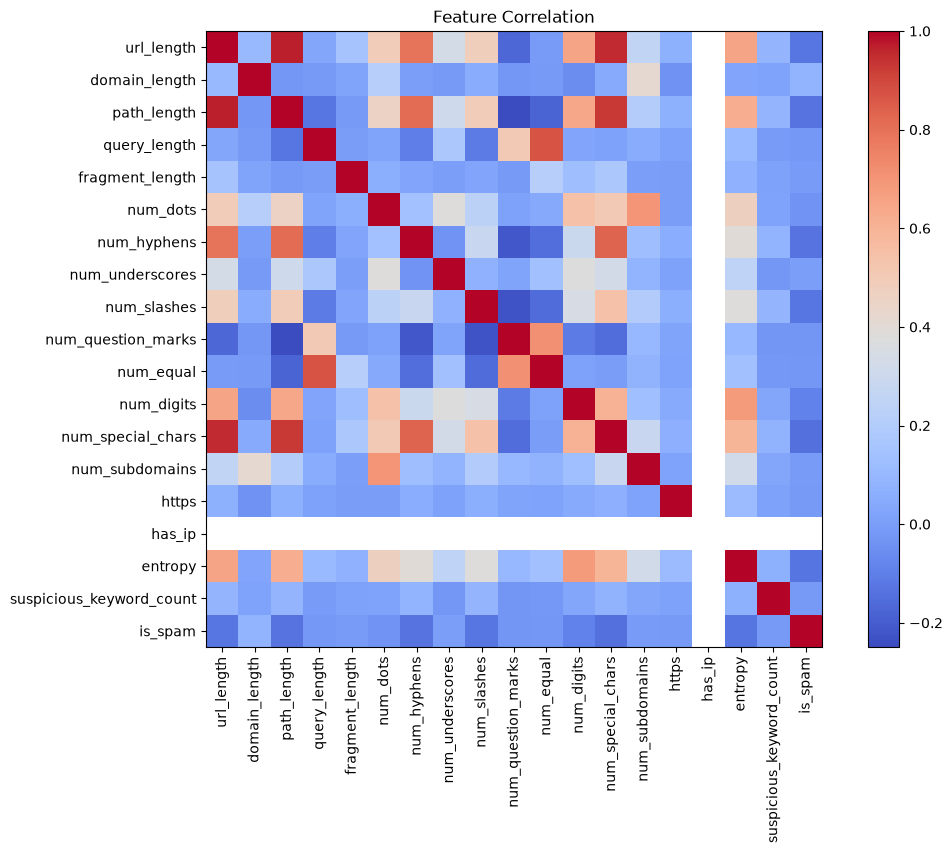

In [58]:
import matplotlib.pyplot as plt

corr = final_df.corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Feature Correlation")

plt.show()

In [59]:
target_corr = (
    final_df
    .corr()["is_spam"]
    .sort_values(ascending=False)
)

print(target_corr)

is_spam                     1.000000
domain_length               0.084946
num_underscores             0.004280
num_subdomains             -0.008986
fragment_length            -0.009811
suspicious_keyword_count   -0.010974
https                      -0.011529
query_length               -0.015146
num_equal                  -0.022789
num_question_marks         -0.028904
num_dots                   -0.032224
num_digits                 -0.090194
num_slashes                -0.123609
url_length                 -0.125337
entropy                    -0.128314
num_hyphens                -0.133092
path_length                -0.133164
num_special_chars          -0.142502
has_ip                           NaN
Name: is_spam, dtype: float64


In [60]:
final_df.to_csv(
    "url_features.csv",
    index=False
)

In [61]:
X = final_df.drop(columns=["is_spam"])
y = final_df["is_spam"]

print(X.shape)
print(y.shape)

(87581, 18)
(87581,)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(70064, 18)
(17517, 18)


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [64]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [65]:
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

print("Training Complete!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training Complete!


In [66]:
from sklearn.model_selection import GridSearchCV

dt_params = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

In [67]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

In [68]:
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

In [70]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

baseline_results = pd.DataFrame(results)

baseline_results

c:\Users\shiva\Desktop\SentinelAI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.968202,0.000000,0.000000,0.000000,0.810471
1,Decision Tree,0.951419,0.231752,0.228007,0.229864,0.645006
2,Random Forest,0.968145,0.497326,0.166966,0.250000,0.780137
3,XGBoost,0.971228,0.747664,0.143627,0.240964,0.864565


In [71]:
tuned_models = {
    "Decision Tree (Tuned)": best_dt,
    "Random Forest (Tuned)": best_rf,
    "XGBoost (Tuned)": best_xgb
}

In [72]:
tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results = pd.DataFrame(tuned_results)

tuned_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree (Tuned),0.959183,0.284153,0.186715,0.225352,0.678851
1,Random Forest (Tuned),0.968202,0.500000,0.165171,0.248313,0.793605
2,XGBoost (Tuned),0.971513,0.795918,0.140036,0.238168,0.868633


In [73]:
comparison = pd.concat(
    [baseline_results, tuned_results],
    ignore_index=True
)

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.968145,0.497326,0.166966,0.250000,0.780137
5,Random Forest (Tuned),0.968202,0.500000,0.165171,0.248313,0.793605
3,XGBoost,0.971228,0.747664,0.143627,0.240964,0.864565
6,XGBoost (Tuned),0.971513,0.795918,0.140036,0.238168,0.868633
1,Decision Tree,0.951419,0.231752,0.228007,0.229864,0.645006
4,Decision Tree (Tuned),0.959183,0.284153,0.186715,0.225352,0.678851
0,Logistic Regression,0.968202,0.000000,0.000000,0.000000,0.810471


In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_xgb.predict(X_test))
print(cm)

[[16940    20]
 [  479    78]]


In [76]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
16,entropy,0.358846
2,path_length,0.131136
0,url_length,0.127468
1,domain_length,0.106443
11,num_digits,0.066431
12,num_special_chars,0.059608
6,num_hyphens,0.044329
8,num_slashes,0.035108
13,num_subdomains,0.022995
5,num_dots,0.016338


In [77]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
3,query_length,0.267510
12,num_special_chars,0.161549
13,num_subdomains,0.071703
11,num_digits,0.059369
1,domain_length,0.059234
8,num_slashes,0.057682
5,num_dots,0.053052
7,num_underscores,0.051318
6,num_hyphens,0.046009
2,path_length,0.036066


In [78]:
RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [79]:
DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [80]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

30.447037701974864


In [81]:
XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


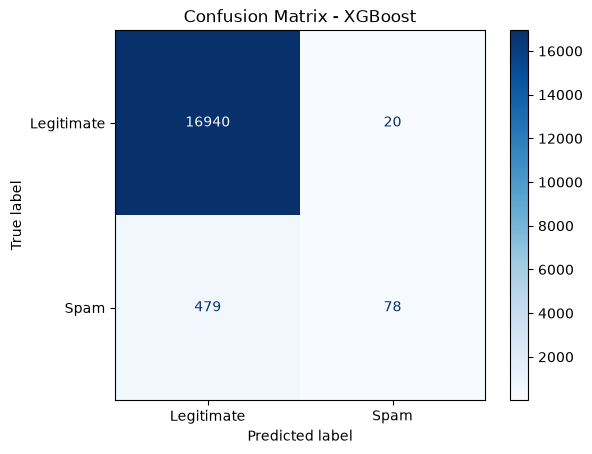

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_xgb,
    X_test,
    y_test,
    display_labels=["Legitimate", "Spam"],
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [84]:
from sklearn.metrics import classification_report

y_pred = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     16960
           1       0.80      0.14      0.24       557

    accuracy                           0.97     17517
   macro avg       0.88      0.57      0.61     17517
weighted avg       0.97      0.97      0.96     17517



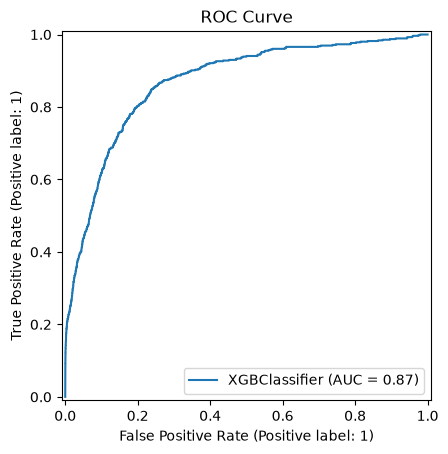

In [85]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)

plt.title("ROC Curve")
plt.show()

In [91]:
import joblib

joblib.dump(
    best_xgb,
    "../../models/phishing/phishing_model.joblib"
)

['../../models/phishing/phishing_model.joblib']

In [92]:
model = joblib.load("../../models/phishing/phishing_model.joblib")

In [93]:
import pickle

with open("../../models/phishing/phishing_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
